<a href="https://colab.research.google.com/github/josuejr3/breast-cancer-classification/blob/main/script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
    <img src="https://github.com/josuejr3/breast-cancer-classification/blob/main/icon.png?raw=1" width="100">
</div>

<div style="font-size: 12px">
    <h4 style="color: black;">Instituto Federal da Paraíba - IFPB</h4>
    <h4 style="color: black;">Disciplina - Inteligência Artificial</h4>
    <h4 style="text-align: center; color: black;">Projeto - Classificação de Tumores de Mama Utilizando Técnicas de Aprendizado de Máquina</h4>
    <h4 style="color: black;">
    Alunos:
</h4>
    <div style="margin-left: 20px; color: black; font-size: 12px;">
        <h4>João Victor Rocha da Costa - 202311250010</h4>
        <h4>Josué Ferreira de Souza Júnior - 202311250001</h4>
        <h4>Vinicius Figueiredo de Queiroz Almeida - 202411250033</h4>
    </div>
</div>

<h4 style="font-size: 15px; color: black;">Objetivo</h4>
<div style="font-size: 15px; color: black;">
    O objetivo deste projeto e desenvolver um sistema de Inteligência Artificial capaz de classificar tumores de mama como
benignos ou malignos a partir de caracter ́ısticas extra ́ıdas de exames médicos.
</div>

<h5 style="font-size: 16px; color: black;">1. Imports de Bibliotecas e Pacotes</h5>

In [1]:
from sklearn.datasets import load_breast_cancer              # Dataset utilizado
import matplotlib.pyplot as plt                              # Biblioteca de visualização de gráficos
from IPython.display import display, Markdown                # Biblioteca para uso markdown
import seaborn as sns                                        # Visualização de gráficos
import pandas as pd                                          # Biblioteca para manipulação de dados tabulares
import numpy as np                                           # Biblioteca para manipulação de narrays

<h5 style="font-size: 16px; color: black;">2. Base de Dados</h5>

In [ ]:
pd.set_option('display.max_columns', None)                   # Mostra todas as colunas do DataFrame
database = load_breast_cancer(as_frame=True)                 # Carrega a base de dados a partir do sklearn
df = database.frame                                          # Cria o dataframe pandas a partir da base de dados

<h4 style="color: black; font-size: 15px;">3. Pré-Processamento e Limpeza dos Dados</h4>

In [ ]:
df.isnull().any()                                            # Verifica se existe valores ausentes nas colunas

mean radius                False
mean texture               False
mean perimeter             False
mean area                  False
mean smoothness            False
mean compactness           False
mean concavity             False
mean concave points        False
mean symmetry              False
mean fractal dimension     False
radius error               False
texture error              False
perimeter error            False
area error                 False
smoothness error           False
compactness error          False
concavity error            False
concave points error       False
symmetry error             False
fractal dimension error    False
worst radius               False
worst texture              False
worst perimeter            False
worst area                 False
worst smoothness           False
worst compactness          False
worst concavity            False
worst concave points       False
worst symmetry             False
worst fractal dimension    False
target    

In [ ]:
df.isna().any()                                             # Verifica se existe valores NaN nas colunas

mean radius                False
mean texture               False
mean perimeter             False
mean area                  False
mean smoothness            False
mean compactness           False
mean concavity             False
mean concave points        False
mean symmetry              False
mean fractal dimension     False
radius error               False
texture error              False
perimeter error            False
area error                 False
smoothness error           False
compactness error          False
concavity error            False
concave points error       False
symmetry error             False
fractal dimension error    False
worst radius               False
worst texture              False
worst perimeter            False
worst area                 False
worst smoothness           False
worst compactness          False
worst concavity            False
worst concave points       False
worst symmetry             False
worst fractal dimension    False
target    

In [ ]:
display(Markdown("Como as duas Series criadas a partir dos métodos .isna().any() e .isnull().any() não apresentaram nenhum valor True, "
                "podemos dizer que o dataset não possui valores ausentes e nem valores do tipo NaN<hr>"))

Como as duas Series criadas a partir dos métodos .isna().any() e .isnull().any() não apresentaram nenhum valor True, podemos dizer que o dataset não possui valores ausentes e nem valores do tipo NaN<hr>

<h4 style="color: black; font-size: 15px;">4. Análise Exploratória de Dados (EDA)</h4>

<h5 style="color: black; font-size: 15px; text-indent: 40px;">4.1 Informações sobre a base de dados</h5>

In [ ]:
amount_inst, amount_attr = df.shape                          # Retorna a quantidade de linha e colunas do dataset
amount_attr = amount_attr - 1                                # Remove da quantidade de colunas o Y
display(Markdown(                                            # Printa q quantidade de instâncias e atributos
    f'A base de dados histórica (dataset) possui o total de {amount_inst} instâncias, '
    f'cada uma delas com {amount_attr} atributos.</p><hr>'
))

A base de dados histórica (dataset) possui o total de 569 instâncias, cada uma delas com 30 atributos.</p><hr>

In [ ]:
df.info()                                                    # Mostra os nomes das colunas, os tipos e quantos valores não nulos elas possuem
display(Markdown("<p style='color: black;'><br>Todas as colunas do dataset são compostas por valores numéricos,"
                 "a coluna target que representa o (Y) é do tipo inteiro de 64 bits,"
                "enquanto o restante são números do tipo float também de "
                 "64 bits e não há valores ausentes.</p><hr>"))
display(Markdown("Descrição estatística sobre "
                "todas as colunas do dataset<hr>"))
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

<p style='color: black;'><br>Todas as colunas do dataset são compostas por valores numéricos,a coluna target que representa o (Y) é do tipo inteiro de 64 bits,enquanto o restante são números do tipo float também de 64 bits e não há valores ausentes.</p><hr>

Descrição estatística sobre todas as colunas do dataset<hr>

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


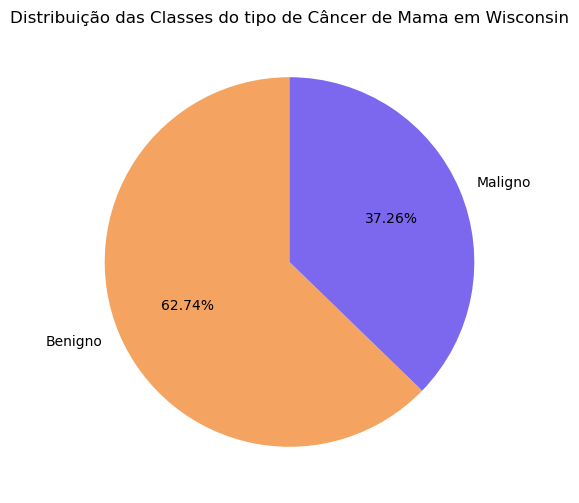

<p>O gráfico de setores criado representa o percentual de cada tipo de caso.</p>

In [ ]:
dist_class = df["target"].value_counts().rename(index={0: "Maligno", 1: "Benigno"})
colors_dist_class = ["#F4A460", "#7B68EE"]
plt.figure(figsize=(6, 6))
plt.pie(
    dist_class,
    labels=dist_class.index,
    autopct="%1.2f%%",
    startangle = 90,
    colors=colors_dist_class,
)
plt.title("Distribuição das Classes do tipo de Câncer de Mama em Wisconsin")
plt.show()

display(Markdown("<p>O gráfico de setores criado representa o percentual de cada tipo de caso.</p>"))


<h4 style="color: black; font-size: 15px;">5. Treinamento de Modelos</h4>

<h5 style="color: black; font-size: 15px; text-indent: 40px;">5.1 Preparação de Dados</h5> Vinicius

<h5 style="color: black; font-size: 15px; text-indent: 40px;">5.2 Regressão Logística</h5>

<h5 style="color: black; font-size: 15px; text-indent: 40px;">5.3 Support Vector Machine (SVM)</h5> Josue

<h5 style="color: black; font-size: 15px; text-indent: 40px;">5.4 Árvores de Decisão</h5> Vinicius

<h5 style="color: black; font-size: 15px; text-indent: 40px;">5.5 Random Forest</h5> Josue

<h4 style="color: black; font-size: 15px;">6. Avaliação</h4>

<h5 style="color: black; font-size: 15px; text-indent: 40px;">6.1 Acurácia</h5> Vinicius

<h5 style="color: black; font-size: 15px; text-indent: 40px;">6.2 Precisão</h5>

<h5 style="color: black; font-size: 15px; text-indent: 40px;">6.3 Sensibilidade (Recall)</h5> Josue

<h5 style="color: black; font-size: 15px; text-indent: 40px;">6.4 F1-score</h5>

<h4 style="color: black; font-size: 15px;">7. Análise de Resultados</h4>